In [1]:
#Here i am gonna run a model in which i handle the outliers and compare results, maybe apply SMOTE aswell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

original_bank = pd.read_csv("/Users/Owner/Desktop/Bank-Project/Datasets/bank/bank-full.csv", sep=";")

X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}


Train shape: (36168, 16)
Test shape: (9043, 16)


In [2]:
# An outlier capping function

#Capping Function

def cap_outliers(X_train_raw, X_test_raw, numeric_cols):
    X_train_capped = X_train_raw.copy()
    X_test_capped = X_test_raw.copy()
    bounds = {}

    for column in numeric_cols:
        q1 = X_train_capped[column].quantile(0.25)
        q3 = X_train_capped[column].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - (1.5 *iqr)
        upper_limit = q3 + (1.5 *iqr)

        X_train_capped[column] = np.where(
            X_train_capped[column] > upper_limit,
            upper_limit,
            np.where(X_train_capped[column] < lower_limit,
                    lower_limit,
                    X_train_capped[column])
        )

        X_test_capped[column] = np.where(
            X_test_capped[column] > upper_limit,
            upper_limit,
            np.where(X_test_capped[column] < lower_limit,
                     lower_limit,
                     X_test_capped[column])
        )

        bounds[column] = {
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_limit": lower_limit,
            "upper_limit": upper_limit
        }
    
    return X_train_capped, X_test_capped, bounds


#Preprocesasing Function Helper

def prepare_prepro(X_train_raw, X_test_raw, categorical_cols, numeric_cols):
    
    # Encoding Categorical Values - to numeric
    X_train_cat = pd.get_dummies(X_train_raw[categorical_cols], drop_first=False)
    X_test_cat = pd.get_dummies(X_test_raw[categorical_cols], drop_first=False)

    # Align columns
    X_train_cat, X_test_cat = X_train_cat.align(
        X_test_cat, join="left", axis=1, fill_value=0
    )

    # Scale numeric variables
    scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_raw[numeric_cols]),
        columns=numeric_cols,
        index=X_train_raw.index
    )

    X_test_num = pd.DataFrame(
        scaler.transform(X_test_raw[numeric_cols]),
        columns=numeric_cols,
        index=X_test_raw.index
    )

    # Combine
    X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
    X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

    return X_train_final, X_test_final


#Evaluation Helper Funtion that is gonna fit the models
def evaluate_models(models, X_train_final, X_test_final, y_train, y_test, scenario_name):
    results = []
    outputs = {}

    for model_name, model in models.items():
        model.fit(X_train_final, y_train)
        y_pred = model.predict(X_test_final)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test_final)
            auc = roc_auc_score(y_test, y_prob)
        else:
            y_prob = None
            auc = np.nan

        results.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": auc,
            "Confusion Matrix": confusion_matrix(y_test, y_pred)
        })

        outputs[model_name] = {
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    return pd.DataFrame(results), outputs


In [3]:
#Running the Baseline in the Network
X_train_base_manual, X_test_base_manual = prepare_prepro(
    X_train, X_test, categorical_cols, numeric_cols
)

baseline_manual_results, baseline_outputs = evaluate_models(
    models=models,
    X_train_final=X_train_base_manual,
    X_test_final=X_test_base_manual,
    y_train=y_train,
    y_test=y_test,
    scenario_name="Baseline"
)

print(baseline_manual_results[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by="F1-score", ascending=False))

#Applying IQR capping function and evaluating the models
X_train_capped, X_test_capped, bounds = cap_outliers(
    X_train_raw=X_train,
    X_test_raw=X_test,
    numeric_cols=numeric_cols
)

X_train_capped_manual, X_test_capped_manual = prepare_prepro(
    X_train_capped, X_test_capped, categorical_cols, numeric_cols
)

capped_manual_results, capped_outputs = evaluate_models(
    models=models,
    X_train_final=X_train_capped_manual,
    X_test_final=X_test_capped_manual,
    y_train=y_train,
    y_test=y_test,
    scenario_name="IQR Capped"
)

print(capped_manual_results[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by="F1-score", ascending=False))

   Scenario                Model  Accuracy  Precision    Recall  F1-score  \
2  Baseline              XGBoost  0.905452   0.626717  0.474480  0.540075   
1  Baseline        Random Forest  0.905452   0.661882  0.392250  0.492582   
0  Baseline  Logistic Regression  0.901250   0.644483  0.347826  0.451811   

    ROC-AUC  
2  0.928747  
1  0.925822  
0  0.905574  
     Scenario                Model  Accuracy  Precision    Recall  F1-score  \
2  IQR Capped              XGBoost  0.902355   0.607099  0.468809  0.529067   
1  IQR Capped        Random Forest  0.902466   0.639683  0.380907  0.477488   
0  IQR Capped  Logistic Regression  0.900697   0.633779  0.358223  0.457729   

    ROC-AUC  
2  0.927693  
1  0.924780  
0  0.905689  


In [4]:
#Comparisson
comparison_manual = pd.concat([baseline_manual_results, capped_manual_results], ignore_index=True)

print(comparison_manual[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by=["Model", "Scenario"]))

     Scenario                Model  Accuracy  Precision    Recall  F1-score  \
0    Baseline  Logistic Regression  0.901250   0.644483  0.347826  0.451811   
3  IQR Capped  Logistic Regression  0.900697   0.633779  0.358223  0.457729   
1    Baseline        Random Forest  0.905452   0.661882  0.392250  0.492582   
4  IQR Capped        Random Forest  0.902466   0.639683  0.380907  0.477488   
2    Baseline              XGBoost  0.905452   0.626717  0.474480  0.540075   
5  IQR Capped              XGBoost  0.902355   0.607099  0.468809  0.529067   

    ROC-AUC  
0  0.905574  
3  0.905689  
1  0.925822  
4  0.924780  
2  0.928747  
5  0.927693  


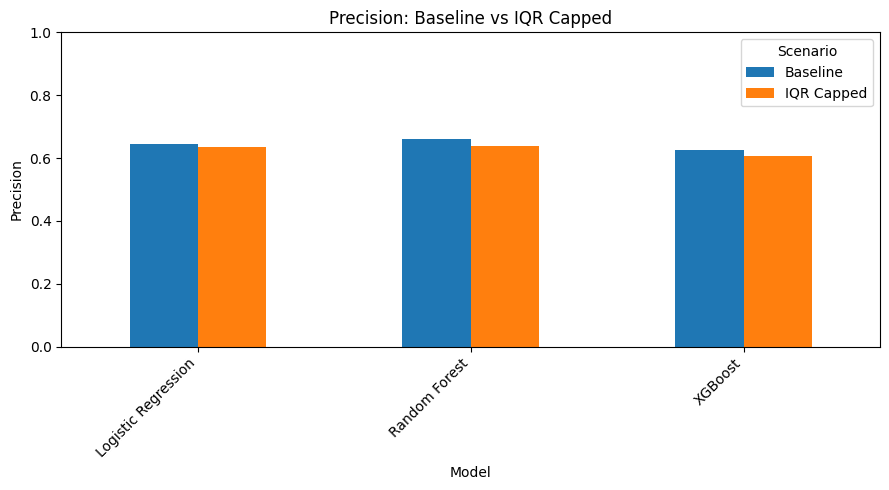

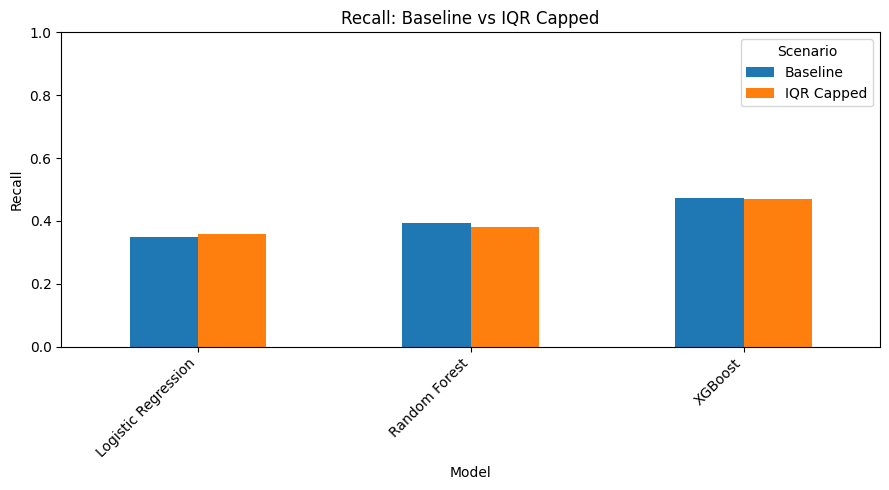

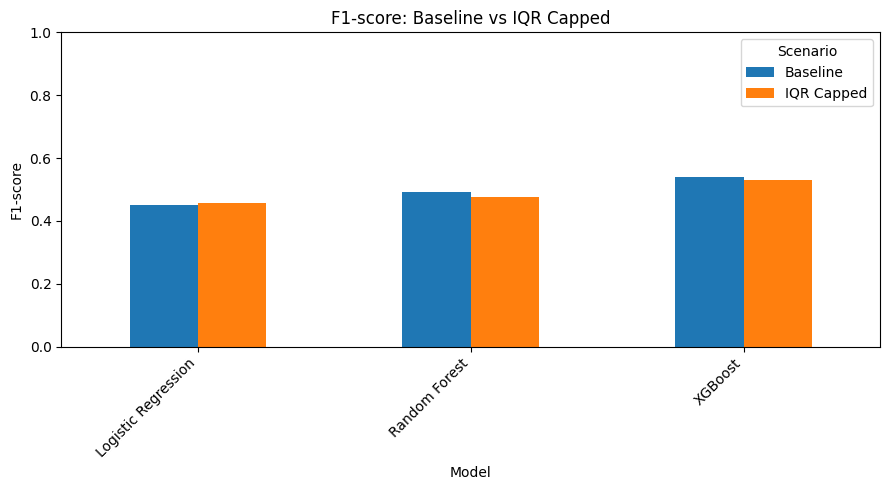

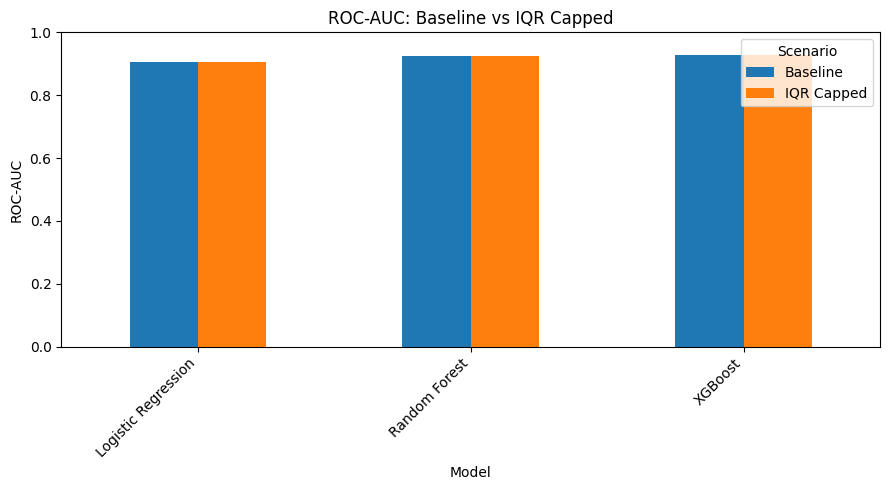

In [5]:
#Plotting the results for comparisson

metrics = ["Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics:
    pivot_df = comparison_manual.pivot(index="Model", columns="Scenario", values=metric)
    pivot_df.plot(kind="bar", figsize=(9, 5))
    plt.title(f"{metric}: Baseline vs IQR Capped")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

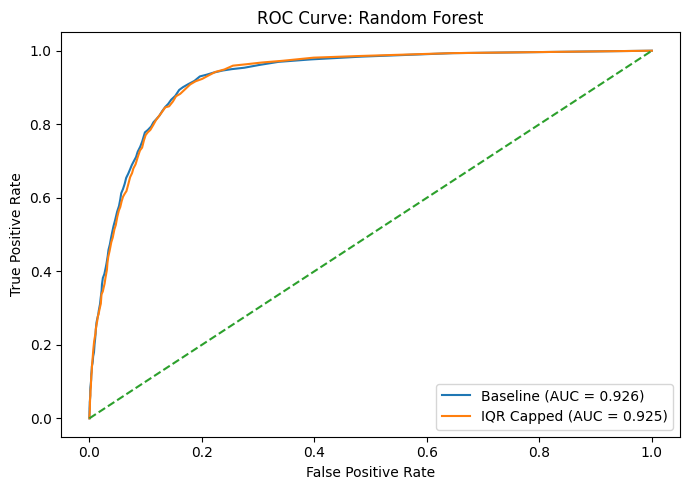

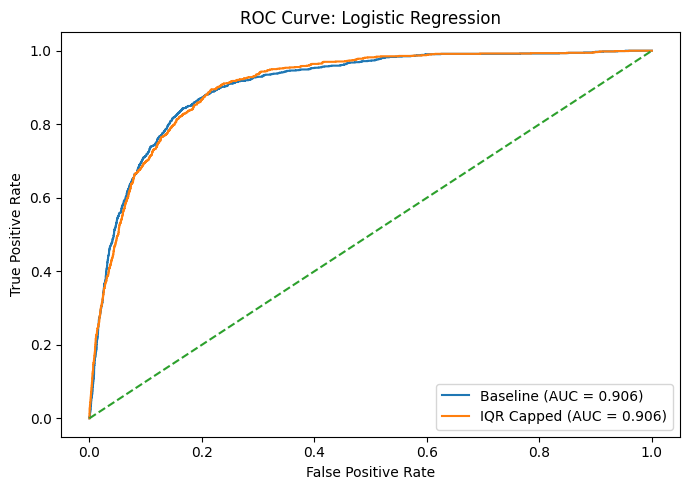

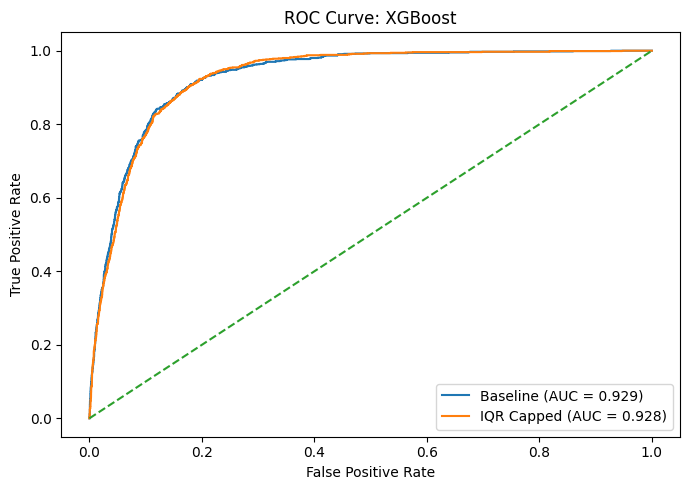

In [7]:
#Plotting ROC curves baseline vs Capped

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

def plot_roc_baseline_vs_capped(model_name, baseline_outputs, capped_outputs, y_test):
    plt.figure(figsize=(7, 5))

    # Baseline
    y_prob_base = baseline_outputs[model_name]["y_prob"]
    fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
    auc_base = roc_auc_score(y_test, y_prob_base)

    # Capped
    y_prob_cap = capped_outputs[model_name]["y_prob"]
    fpr_cap, tpr_cap, _ = roc_curve(y_test, y_prob_cap)
    auc_cap = roc_auc_score(y_test, y_prob_cap)

    plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.3f})")
    plt.plot(fpr_cap, tpr_cap, label=f"IQR Capped (AUC = {auc_cap:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc_baseline_vs_capped("Random Forest", baseline_outputs, capped_outputs, y_test)
plot_roc_baseline_vs_capped("Logistic Regression", baseline_outputs, capped_outputs, y_test)
plot_roc_baseline_vs_capped("XGBoost", baseline_outputs, capped_outputs, y_test)

We got almost the same results, so probably a better approach would be SMOTE or Outliers + SMOTE

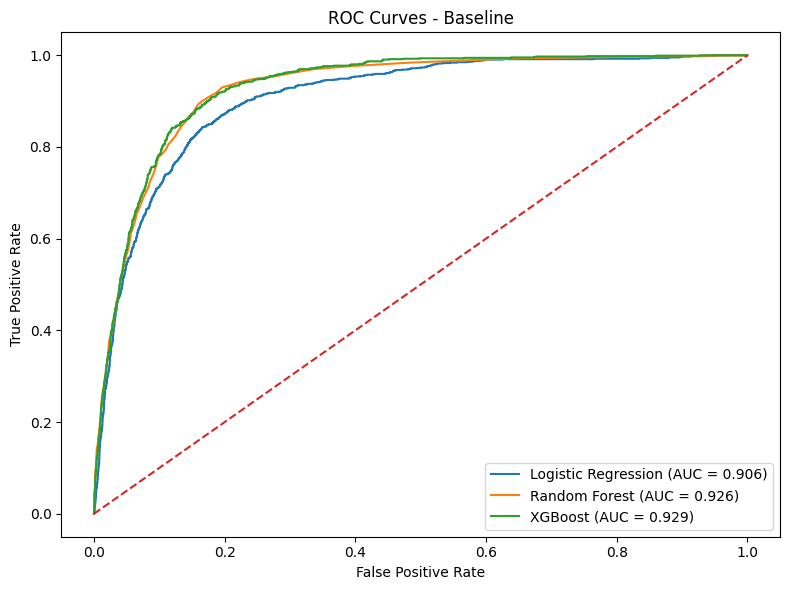

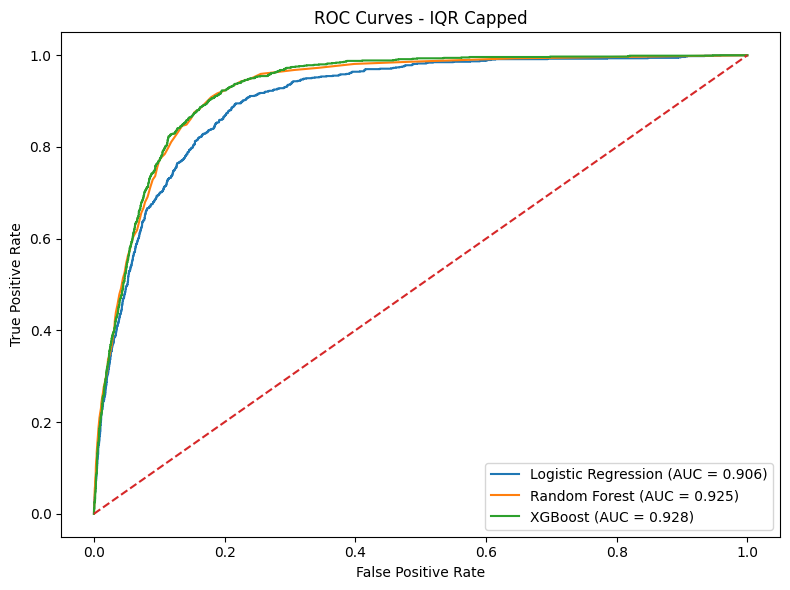

In [8]:
def plot_roc_all_models(outputs_dict, y_test, title):
    plt.figure(figsize=(8, 6))

    for model_name, output in outputs_dict.items():
        y_prob = output["y_prob"]
        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc_all_models(baseline_outputs, y_test, "ROC Curves - Baseline")
plot_roc_all_models(capped_outputs, y_test, "ROC Curves - IQR Capped")

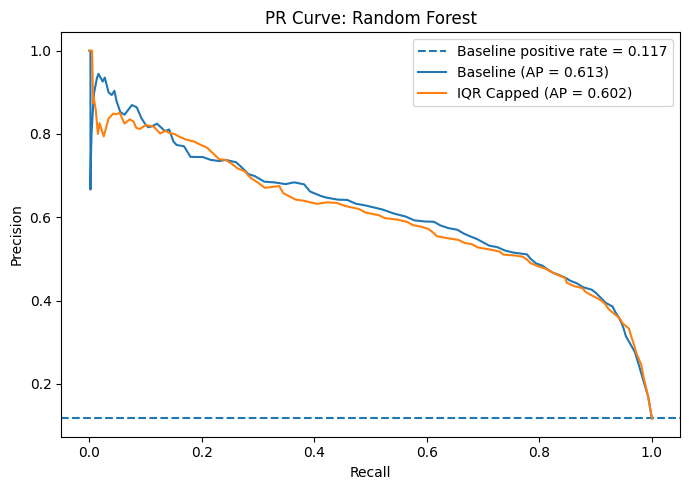

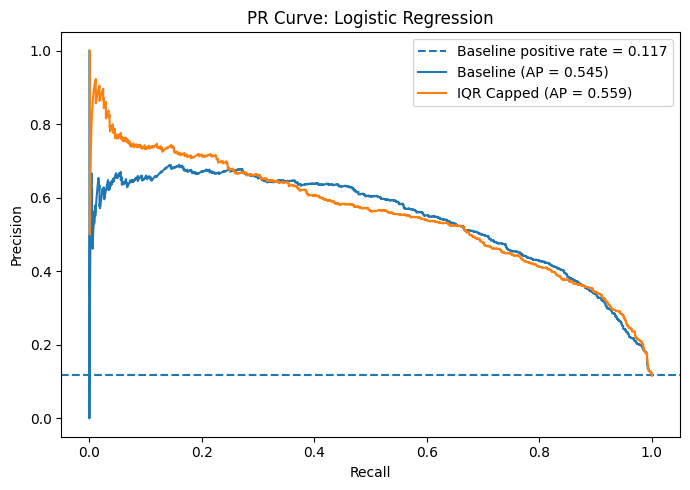

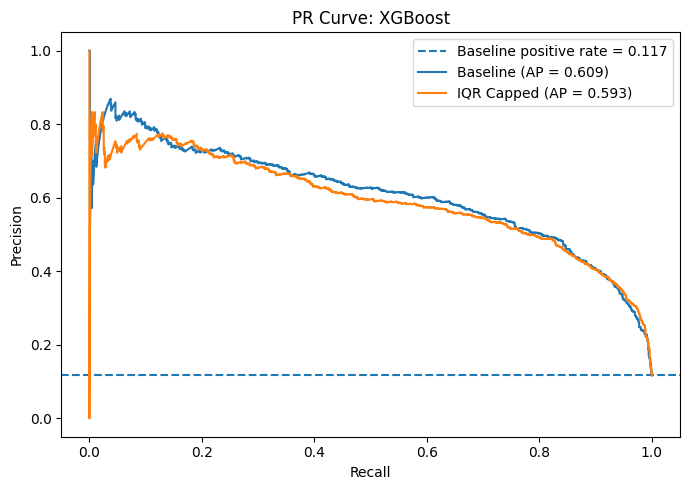

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_baseline_vs_capped(model_name, baseline_outputs, capped_outputs, y_test):
    plt.figure(figsize=(7, 5))

    positive_rate = y_test.mean()
    plt.axhline(y=positive_rate, linestyle="--", label=f"Baseline positive rate = {positive_rate:.3f}")

    # Baseline
    y_prob_base = baseline_outputs[model_name]["y_prob"]
    precision_base, recall_base, _ = precision_recall_curve(y_test, y_prob_base)
    ap_base = average_precision_score(y_test, y_prob_base)

    # Capped
    y_prob_cap = capped_outputs[model_name]["y_prob"]
    precision_cap, recall_cap, _ = precision_recall_curve(y_test, y_prob_cap)
    ap_cap = average_precision_score(y_test, y_prob_cap)

    plt.plot(recall_base, precision_base, label=f"Baseline (AP = {ap_base:.3f})")
    plt.plot(recall_cap, precision_cap, label=f"IQR Capped (AP = {ap_cap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pr_baseline_vs_capped("Random Forest", baseline_outputs, capped_outputs, y_test)
plot_pr_baseline_vs_capped("Logistic Regression", baseline_outputs, capped_outputs, y_test)
plot_pr_baseline_vs_capped("XGBoost", baseline_outputs, capped_outputs, y_test)